In [1]:
from pathlib import Path
from functools import partial

import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import mlflow
from scipy.ndimage import zoom
from unxpass.components.utils import log_model, load_model
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
from unxpass.databases import SQLiteDatabase
from unxpass.datasets import PassesDataset, CompletedPassesDataset, FailedPassesDataset, SamePassesDataset
from unxpass.components import pass_value, pass_value_custom, pass_success
pd.options.mode.chained_assignment = None
from os import listdir
from os.path import isfile, join

In [2]:
homedr = "/home/lz80/rdf/sp161/shared/soccer-decision-making/Bundesliga/features_50"
targetdr = "/home/lz80/rdf/sp161/shared/soccer-decision-making/Bundesliga/features_50_custom"
success = pd.read_parquet("/home/lz80/rdf/sp161/shared/soccer-decision-making/Bundesliga/features_50/y_success.parquet")
successidxs = success[success.values].index
failidxs = success[~success.values].index

In [6]:
def addVals(idx, amount, df, column, changeVal = None, otherVal = None):
    if changeVal is not None and otherVal is not None:
        df[column] = otherVal
        df[column].loc[idx] = changeVal
    else:
        df[column].loc[idx] = df[column].loc[idx] + amount
    return df
def editFiles(homedr, targetdr, stopping, idx, amount, allFilter = None, rmvOthers = False, changeVal = None, otherVal = None):
    allfiles = [f for f in listdir(homedr) if isfile(join(homedr, f))]
    for file in allfiles:
        df = pd.read_parquet(f"{homedr}/{file}")
        print(f"Reading {file}")
        if file == stopping:
            if allFilter is not None:
                df = df.loc[allFilter]
            if rmvOthers:
                df[stopping.split(".")[0][2:]] = 0
            df = addVals(idx, amount, df, stopping.split(".")[0][2:], changeVal, otherVal)
        
        df.to_parquet(f"{targetdr}/{file}")


In [ ]:
editFiles(homedr, targetdr, "y_scores_xg.parquet", successidxs, 1, rmvOthers = True, changeVal = True, otherVal = False)

Reading x_speed.parquet
Reading y_concedes_xg.parquet
Reading x_endlocation.parquet
Reading y_scores_xg.parquet
Reading y_scores.parquet
Reading x_freeze_frame_360.parquet
Reading x_startlocation.parquet
Reading y_concedes.parquet
Reading y_success.parquet


In [15]:
freeze_frame = pd.read_parquet(f"{homedr}/x_freeze_frame_360.parquet")
success = pd.read_parquet(f"{homedr}/y_success.parquet")
ends = pd.read_parquet(f"{homedr}/x_endlocation.parquet")
endvaluesframe = freeze_frame.join(ends).join(success)
endvaluesframe
def distance(x1, x2, y1, y2):
    return np.sqrt((x1 - x2)**2 + (y1-y2)**2)
def closestTeammate(row):
    end_x = row['end_x_a0']
    end_y = row['end_y_a0']
    frame = row['freeze_frame_360_a0']
    teammates = [player for player in frame if player['teammate'] and not player['actor']]
    teammates_x = [player['x'] for player in teammates]
    teammates_y = [player['y'] for player in teammates]
    opponents = [player for player in frame if not player['teammate']]
    opponents_x = [player['x'] for player in opponents]
    opponents_y = [player['y'] for player in opponents]
    team_distances = []
    opp_distances = []
    for idx in range(len(teammates)):
        teammate_dist = distance(end_x, teammates_x[idx], end_y, teammates_y[idx])
        team_distances.append(teammate_dist)
    for idx in range(len(opponents)):
        opp_dist = distance(end_x, opponents_x[idx], end_y, opponents_y[idx])
        opp_distances.append(opp_dist)
    #print(end_x, end_y)
    #print([[opponents_x[i], opponents_y[i]] for i in range(len(opponents))])
    #print(opp_distances)
    return min(team_distances), min(opp_distances)
freeze_frame
samplerow = ("DFL-MAT-J03YE4", 0)
endvaluesframe[['closestTeammate', 'closestOpp']] = pd.DataFrame(
    endvaluesframe.apply(lambda row: closestTeammate(row), axis=1).tolist(),
    index=endvaluesframe.index
)
def getIdx(df, threshold, successOnly = False, failOnly = False):
    filtered = df[((df['closestTeammate'] < threshold))]
    if successOnly:
        return filtered[filtered['success']].index
    if failOnly:
        return filtered[~filtered['success']].index
    return filtered.index



In [4]:
endvaluesframe

freeze_frame_360_a0  \
game_id        action_id                                                      
DFL-MAT-J03YE4 0          [{'actor': False, 'keeper': False, 'teammate':...   
               1          [{'actor': False, 'keeper': False, 'teammate':...   
               3          [{'actor': False, 'keeper': False, 'teammate':...   
               5          [{'actor': False, 'keeper': False, 'teammate':...   
               7          [{'actor': False, 'keeper': False, 'teammate':...   
...                                                                     ...   
DFL-MAT-J03YMB 1496       [{'actor': False, 'keeper': False, 'teammate':...   
               1497       [{'actor': True, 'keeper': False, 'teammate': ...   
               1499       [{'actor': False, 'keeper': False, 'teammate':...   
               1501       [{'actor': False, 'keeper': False, 'teammate':...   
               1503       [{'actor': False, 'keeper': False, 'teammate':...   

                                                        freeze_frame_360_a1  \
game_id        action_id                                                      
DFL-MAT-J03YE4 0          [{'actor': False, 'keeper': False, 'teammate':...   
               1          [{'actor': False, 'keeper': False, 'teammate':...   
               3                                                       None   
               5                                                       None   
               7                                                       None   
...                                                                     ...   
DFL-MAT-J03YMB 1496                                                    None   
               1497       [{'actor': False, 'keeper': False, 'teammate':...   
               1499                                                    None   
               1501                                                    None   
               1503                                                    None   

                                                        freeze_frame_360_a2  \
game_id        action_id                                                      
DFL-MAT-J03YE4 0          [{'actor': False, 'keeper': False, 'teammate':...   
               1          [{'actor': False, 'keeper': False, 'teammate':...   
               3          [{'actor': False, 'keeper': False, 'teammate':...   
               5          [{'actor': False, 'keeper': False, 'teammate':...   
               7          [{'actor': False, 'keeper': False, 'teammate':...   
...                                                                     ...   
DFL-MAT-J03YMB 1496       [{'actor': False, 'keeper': False, 'teammate':...   
               1497                                                    None   
               1499       [{'actor': True, 'keeper': False, 'teammate': ...   
               1501       [{'actor': False, 'keeper': False, 'teammate':...   
               1503       [{'actor': False, 'keeper': False, 'teammate':...   

                           end_x_a0   end_y_a0   end_x_a1   end_y_a1  \
game_id        action_id                                               
DFL-MAT-J03YE4 0          30.077263  28.942396  30.077263  28.942396   
               1          75.468511  50.084784  30.077263  28.942396   
               3          63.918059  49.124622  63.918059  49.124622   
               5           4.477139  40.454925  11.357233  58.622694   
               7          23.814737  10.445159   7.198298  38.289854   
...                             ...        ...        ...        ...   
DFL-MAT-J03YMB 1496       34.795868   5.559629  19.800545   9.108463   
               1497       43.818151  16.441464  34.795868   5.559629   
               1499       55.918624  24.038039  47.147228  18.606535   
               1501       55.156313  27.464499  48.691148  24.452227   
               1503       65.819011  41.923408  57.964318  29.356583   

                           end_x_a2

In [19]:
editFiles(homedr, targetdr, "y_scores_xg.parquet", getIdx(endvaluesframe, 5, successOnly = False), 0.3)

Reading x_speed.parquet
Reading y_concedes_xg.parquet
Reading x_endlocation.parquet
Reading y_scores_xg.parquet
Reading y_scores.parquet
Reading x_freeze_frame_360.parquet
Reading x_startlocation.parquet
Reading y_concedes.parquet
Reading y_success.parquet


In [37]:
success = pd.read_parquet(f"{homedr}/y_success.parquet")
scores_xg = pd.read_parquet(f"{homedr}/y_scores_xg.parquet")
success.join(scores_xg)
scores_xg
#success = success.rename(c
# solumns={'scores_xg': 'success'})
#success.to_parquet(f"{targetdr}/y_success.parquet")

scores_xg
game_id        action_id           
DFL-MAT-J03YE4 0                0.0
               1                0.0
               3                0.0
               5                0.0
               7                0.0
...                             ...
DFL-MAT-J03YMB 1496             0.0
               1497             0.0
               1499             0.0
               1501             0.0
               1503             0.0

[47618 rows x 1 columns]

In [22]:
##Testing Results
dataset_test = partial(PassesDataset, path = targetdr)
value_fail_defensive = pass_value_custom.SoccerMapComponent(model = pass_value_custom.PytorchSoccerMapModel())
labs = value_fail_defensive.initialize_dataset(dataset_test, model_name = "val").labels
#labs['scores'].mean(), labs['scores_xg'].mean()
labs['scores_xg'].unique()

[11/22/24 09:13:50] INFO     Loading dataset from                                                   ]8;id=469995;file:///home/lz80/un-xPass/.venv/lib/python3.10/site-packages/lightning_utilities/core/rank_zero.py\rank_zero.py]8;;\:]8;id=622583;file:///home/lz80/un-xPass/.venv/lib/python3.10/site-packages/lightning_utilities/core/rank_zero.py#32\32]8;;\
                             /home/lz80/rdf/sp161/shared/soccer-decision-making/Bundesliga/features                
                             _50_custom                                                                            

array([0.3   , 0.    , 0.3258, ..., 0.3861, 0.0861, 0.3475])

In [28]:
DATA_DIR = Path("../stores/")
dbpath = "/home/lz80/rdf/sp161/shared/soccer-decision-making/buli_50.sql"
db = SQLiteDatabase(dbpath)
db.actions(game_id = "DFL-MAT-J03YE4")

original_event_id  period_id  time_seconds team_id  \
game_id        action_id                                                      
DFL-MAT-J03YE4 0          18454000000006.0          1           0.0       0   
               1          18454000000007.0          1           3.0       0   
               2                      None          1           4.5       0   
               3          18454000000015.0          1           6.0       0   
               4                      None          1          10.5       0   
...                                    ...        ...           ...     ...   
               1632       18454000001614.0          2        3049.0       0   
               1633                   None          2        3050.0       0   
               1634       18454000001615.0          2        3051.0       0   
               1635                   None          2        3054.0       0   
               1636       18454000001618.0          2        3057.0       0   

                               player_id    start_x    start_y      end_x  \
game_id        action_id                                                    
DFL-MAT-J03YE4 0          DFL-OBJ-002G82  53.655239  33.786127  74.922737   
               1          DFL-OBJ-J01ILL  72.606857  38.521043  29.531489   
               2          DFL-OBJ-0026MA  29.531489  17.915216  41.081941   
               3          DFL-OBJ-0026MA  41.081941  18.875378  41.081941   
               4          DFL-OBJ-0027IT  41.081941  18.875378  93.642767   
...                                  ...        ...        ...        ...   
               1632       DFL-OBJ-J01ILL  48.656798  22.668959  48.589252   
               1633       DFL-OBJ-0002E5  48.589252  39.057604  47.778694   
               1634       DFL-OBJ-0002E5  47.778694  43.067692  34.346590   
               1635       DFL-OBJ-002G41  34.346590  59.023324  81.484397   
               1636       DFL-OBJ-002G41  81.484397  56.293452  81.484397   

                              end_y  bodypart_id  type_id  result_id  \
game_id        action_id                                               
DFL-MAT-J03YE4 0          39.057604            5        0          1   
               1          17.915216            5        0          0   
               2          18.875378            0       21          1   
               3          18.875378            5        0          0   
               4           9.377306            0       21          1   
...                             ...          ...      ...        ...   
               1632       39.057604            5        0          1   
               1633       43.067692            0       21          1   
               1634       59.023324            5        0          1   
               1635       56.293452            0       21          1   
               1636       56.293452            0        9          1   

                         possession_team_id play_pattern_name  under_pressure  \
game_id        action_id                                                        
DFL-MAT-J03YE4 0             DFL-CLU-00000D     From Kick Off               0   
               1             DFL-CLU-00000D     From Kick Off               0   
               2                       None              None               0   
               3             DFL-CLU-00000D              None               0   
               4                       None              None               0   
...                                     ...               ...             ...   
               1632          DFL-CLU-00000D              None               0   
               1633                    None              None               0   
               1634          DFL-CLU-00000D              None               0   
               1635                    None              None               0   
               1636          DFL-CLU-00000D              None               0   

    

<Axes: >

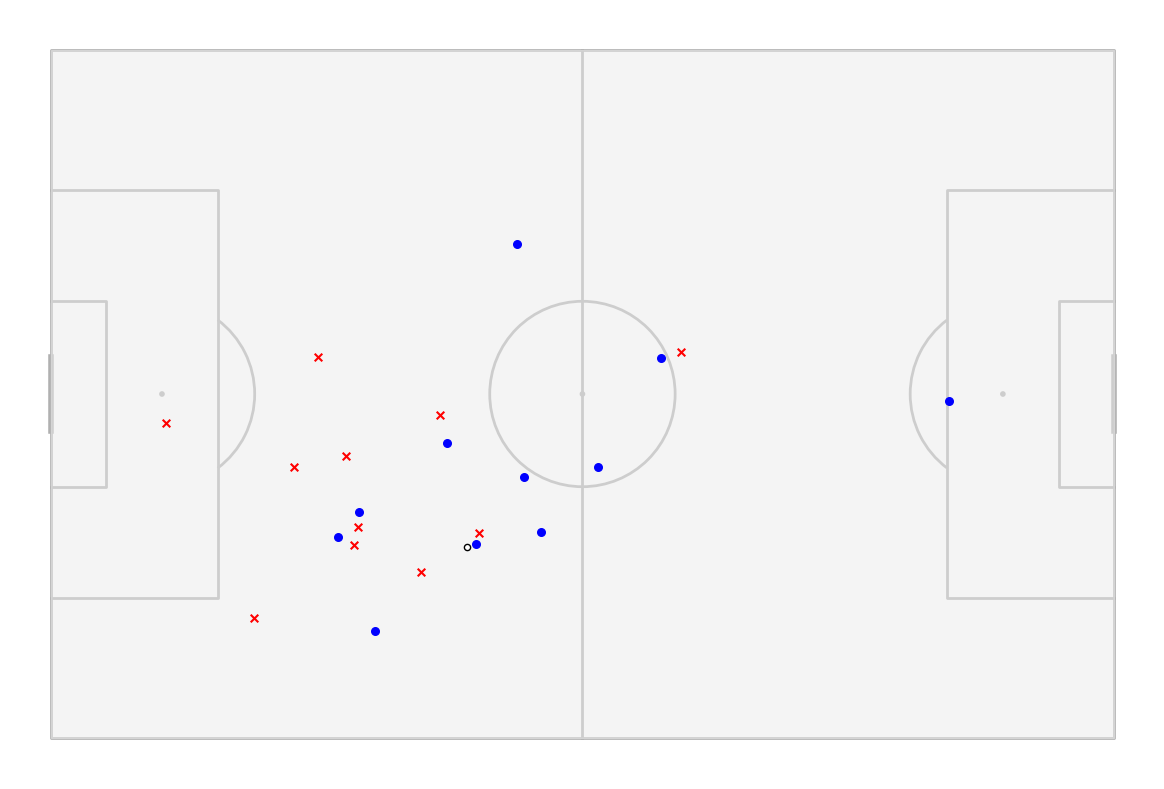

In [30]:
action_id = 3
game_id = "DFL-MAT-J03YE4"
from unxpass.visualization import plot_action_og
plot_action_og(db.actions(game_id = game_id).loc[(game_id, action_id)], show_action = True)